## Objetivos:

1. ¿Cuáles son los 10 productos más vendidos en cantidad?
2. ¿Cuáles son los 10 productos que generan más ingresos?
3. ¿Quiénes son los 20 clientes que más compran en términos de ingresos?
4. ¿Cuál es la compra media por cliente mensualmente?
5. ¿Cuántos pedidos totales se han realizado?
6. ¿Cuál es el valor promedio por pedido mensualmente?
7.  ¿Cuál es el método de pago que más se utiliza?
8.  ¿En qué ciudades generan más ingresos?
9.  ¿En qué ciudades se realizaron más compras en cantidad?
10. ¿Cuál es el ingreso total generado?
11. ¿Cómo ha sido la tendencia de ingresos?
12. ¿Cuál es la cantidad total vendida?
13. ¿Cómo ha sido la tendencia de la cantidad vendida?
14. ¿Cuáles son las categorías más vendidas en cantidad?
15. ¿Qué categorías generan más ingresos?

Instalamos el paquete **sqlalchemy**. La cual nos permite conectar Python con SQLserver.

In [1]:
# !pip install sqlalchemy

Importamos los paquetes necesarios

In [2]:
import sqlalchemy
from sqlalchemy import create_engine
import urllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Proyecto_Tienda_Aurelion;"
    "Trusted_Connection=yes;"
    "Encrypt=optional;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

con = engine.connect()
print("Conexión exitosa")


C:\Users\HP\AppData\Local\Temp\ipykernel_12912\2203891210.py:11: SAWarning: Unrecognized server version info '17.0.800.3'.  Some SQL Server features may not function properly.
  con = engine.connect()


Conexión exitosa


##  Análisis Exploratorio de datos 



In [4]:
query1 = '''
        SELECT *, YEAR(fecha) AS año, MONTH(fecha) AS mes FROM dbo.ventas'''
df_fecha_ventas = pd.read_sql(query1, con)
df_fecha_ventas.head()

,id_venta,fecha,id_cliente,id_medio_pago,año,mes
0,1,2024-06-19,62,1,2024,6
1,2,2024-03-17,49,2,2024,3
2,3,2024-01-13,20,1,2024,1
3,4,2024-02-27,36,3,2024,2
4,5,2024-06-11,56,1,2024,6


* Las ventas se realizaron desde enero hasta junio de 2024

In [5]:
month = np.sort(df_fecha_ventas['mes'].unique())
year = df_fecha_ventas['año'].unique()
print(f"meses = {month}")
print(f"año = {year}")

meses = [1 2 3 4 5 6]
año = [2024]


* Se observa que las ciudades son del país de Argentina.

In [6]:
query2 = "SELECT * FROM dbo.ciudades"
df_ciudades = pd.read_sql(query2, con)
df_ciudades.head()

,id_ciudad,ciudad
0,1,Carlos Paz
1,2,Rio Cuarto
2,3,Cordoba
3,4,Villa Maria
4,5,Alta Gracia


#### Distribución de precios mediante diagrama de caja e histograma, respectivamente.

In [7]:
query_productos = '''SELECT * FROM dbo.productos'''
df_productos = pd.read_sql(query_productos, con)
df_productos.head()

,id_producto,nombre_producto,precio_unitario,id_categoria
0,1,Coca Cola 1.5L,2347.0,1
1,2,Pepsi 1.5L,4973.0,2
2,3,Sprite 1.5L,4964.0,1
3,4,Fanta Naranja 1.5L,2033.0,2
4,5,Agua Mineral 500ml,4777.0,1


In [8]:
df_productos['precio_unitario'].describe()

count     100.000000
mean     2718.550000
std      1381.635324
min       272.000000
25%      1590.000000
50%      2516.000000
75%      4026.500000
max      4982.000000
Name: precio_unitario, dtype: float64

Se observa que la media  es mayor que la mediana. Por lo tanto, la distribución es asimétrica con cola a la derecha (sesgada a la derecha).

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


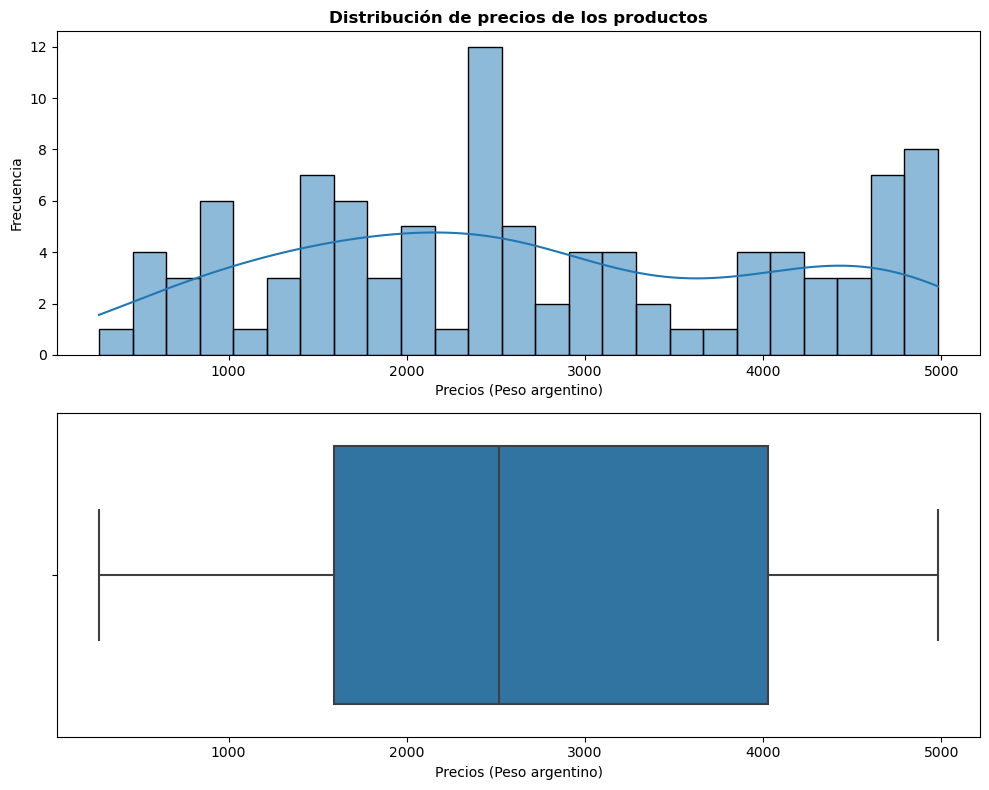

In [9]:
# Visualizaciones
plt.figure(figsize=(10, 8))

# Gráfico de distribución de precios de alquiler
plt.subplot(2, 1, 1)
sns.histplot(data= df_productos, x = 'precio_unitario', stat='count', bins= 25, kde = True)
plt.title('Distribución de precios de los productos',weight='bold')
plt.xlabel('Precios (Peso argentino)')
plt.ylabel('Frecuencia')

#plt.xlim(0, 5000)
# Gráfico de caja
plt.subplot(2, 1, 2)
sns.boxplot(data= df_productos, x= 'precio_unitario')
plt.xlabel('Precios (Peso argentino)')
plt.tight_layout()
plt.show()

#### Análisis del histograma:

- El eje $x$ representa el precio en pesos argentinos, mientras que el eje $y$ muestra la frecuencia de productos en los distintos niveles de precio. Se observa una ligera asimetría positiva (sesgo hacia la derecha), lo que indica que existen algunos productos con precios relativamente altos.

#### Análisis del gráfico de caja y bigote:
- Se observa que el 50% de los productos su precio está entre 1590 y 4026.5 pesos argentinos. No se observan valores atípicos.

#### Distribución de las ventas totales (Importe) mediante diagrama de caja e histograma, respectivamente.

In [10]:
query_detalle_ventas = '''SELECT *, (cantidad * precio_unitario) AS importe FROM dbo.detalle_ventas'''
df_detalle_ventas = pd.read_sql(query_detalle_ventas, con)
df_detalle_ventas.head()

,id_venta,id_producto,cantidad,precio_unitario,importe
0,1,90,1,2902.0,2902.0
1,2,22,1,2069.0,2069.0
2,2,39,5,469.0,2345.0
3,2,70,2,4061.0,8122.0
4,2,79,4,2420.0,9680.0


In [11]:
df_detalle_ventas['importe'].describe()

count      343.000000
mean      7730.078717
std       5265.543077
min        272.000000
25%       3489.000000
50%       6702.000000
75%      10231.500000
max      24865.000000
Name: importe, dtype: float64

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


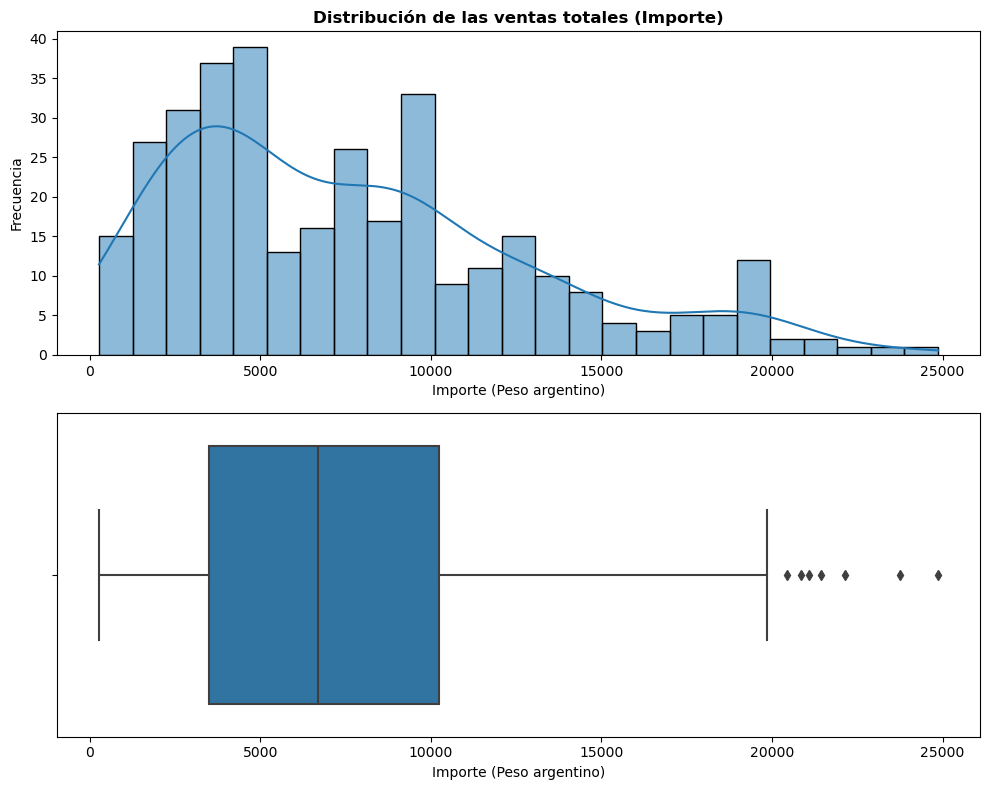

In [12]:
# Visualizaciones
plt.figure(figsize=(10, 8))

# Gráfico de distribución de precios de alquiler
plt.subplot(2, 1, 1)
sns.histplot(data= df_detalle_ventas, x = 'importe', stat='count', bins= 25, kde = True)
plt.title('Distribución de las ventas totales (Importe)',weight='bold')
plt.xlabel('Importe (Peso argentino)')
plt.ylabel('Frecuencia')

#plt.xlim(0, 5000)
# Gráfico de caja
plt.subplot(2, 1, 2)
sns.boxplot(data= df_detalle_ventas, x= 'importe')
plt.xlabel('Importe (Peso argentino)')
plt.tight_layout()
plt.show()

Encontrar el límite superior e límite inferior del boxplot.

In [13]:
rango_intercuartilico = df_detalle_ventas['importe'].quantile(0.75) - df_detalle_ventas['importe'].quantile(0.25)
# limite_inferior_importe = df_detalle_ventas['importe'].quantile(0.25) - (1.5 * (rango_intercuartilico))
limite_superior_importe = df_detalle_ventas['importe'].quantile(0.75) +  (1.5 * (rango_intercuartilico))
# print(round(limite_inferior_importe, 0))
print(round(limite_superior_importe, 0))

20345.0


Encontramos los valores atípicos


In [14]:
query_producto_detalle_ventas = '''
                                SELECT *, (dv.cantidad * dv.precio_unitario) AS importe FROM dbo.detalle_ventas AS dv
                                INNER JOIN dbo.productos AS prod ON prod.id_producto = dv.id_producto
                                WHERE (dv.cantidad * dv.precio_unitario) >= 20345.0;
                                '''
df_unir_producto_detalle_ventas = pd.read_sql(query_producto_detalle_ventas, con)
df_unir_producto_detalle_ventas

,id_venta,id_producto,cantidad,precio_unitario,id_producto,nombre_producto,precio_unitario,id_categoria,importe
0,16,35,5,4430.0,35,Barrita de Cereal 30g,4430.0,1,22150.0
1,21,76,5,4286.0,76,Pizza Congelada Muzzarella,4286.0,2,21430.0
2,50,58,5,4752.0,58,Caramelos Masticables,4752.0,2,23760.0
3,63,8,5,4218.0,8,Energética Nitro 500ml,4218.0,2,21090.0
4,75,2,5,4973.0,2,Pepsi 1.5L,4973.0,2,24865.0
5,94,86,5,4090.0,86,Jugo en Polvo Limón,4090.0,2,20450.0
6,110,6,5,4170.0,6,Jugo de Naranja 1L,4170.0,2,20850.0


### ¿Cuál es el ingreso total generado?

In [15]:
query_importe_total = '''
                        SELECT SUM(detalle_ventas_importe.importe) AS "Importe Total"
                        FROM (SELECT *, (dv.cantidad * dv.precio_unitario) AS importe FROM dbo.detalle_ventas AS dv) AS detalle_ventas_importe;
                      '''
importe_total = pd.read_sql(query_importe_total, con)
importe_total

,Importe Total
0,2651417.0


### ¿Cuál es la cantidad total vendida?

In [16]:
query_cantidad_total = '''SELECT SUM(dv.cantidad) AS "Cantidad  Total Vendida" 
                          FROM dbo.detalle_ventas AS dv'''
cantidad_vendida = pd.read_sql(query_cantidad_total, con)
cantidad_vendida

,Cantidad Total Vendida
0,1016


### ¿Cómo ha sido la tendencia de los ingresos mensualmente?

In [17]:
query_tendencia_ingresos = ''' 
                               SELECT MONTH(vt.fecha) AS mes, FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, SUM(dv.cantidad * dv.precio_unitario) AS importe 
                               FROM dbo.detalle_ventas AS dv 
                               INNER JOIN dbo.ventas vt ON vt.id_venta = dv.id_venta
                               GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                               ORDER BY MONTH(vt.fecha) ASC ;
                            '''
df_tendencia_ingresos = pd.read_sql(query_tendencia_ingresos, con)
df_tendencia_ingresos

,mes,nombre_mes,importe
0,1,enero,529840.0
1,2,febrero,407041.0
2,3,marzo,388263.0
3,4,abril,251524.0
4,5,mayo,561832.0
5,6,junio,512917.0


In [18]:
crecimiento_mes_a_mes = np.zeros(6)
for i in range(6):
    if i == 0:
        crecimiento_mes_a_mes[i] = np.nan
    else:    
        crecimiento_mes_a_mes[i] = round(((df_tendencia_ingresos['importe'][i] - df_tendencia_ingresos['importe'][i - 1]) / df_tendencia_ingresos['importe'][i - 1]) * 100,1)

print(crecimiento_mes_a_mes)

[  nan -23.2  -4.6 -35.2 123.4  -8.7]


Calculamos el crecimiento mes a mes del importe

In [19]:
df_tendencia_ingresos['crecimiento_mes_a_mes (%)'] = crecimiento_mes_a_mes
df_tendencia_ingresos

,mes,nombre_mes,importe,crecimiento_mes_a_mes (%)
0,1,enero,529840.0,NaN
1,2,febrero,407041.0,-23.2
2,3,marzo,388263.0,-4.6
3,4,abril,251524.0,-35.2
4,5,mayo,561832.0,123.4
5,6,junio,512917.0,-8.7


Tasa de Crecimiento Mensual Compuesta (CMGR) del importe

In [20]:
CMGR = round((((df_tendencia_ingresos['importe'][5] / df_tendencia_ingresos['importe'][0]) ** (1 / (df_tendencia_ingresos.shape[0]-1))) - 1) * 100,1)
print(f'Tasa de Crecimiento Mensual Compuesta = {CMGR}%')

Tasa de Crecimiento Mensual Compuesta = -0.6%


En promedio, los ingresos de la tienda decrecieron un -0.6% mensual entre enero y junio. 

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


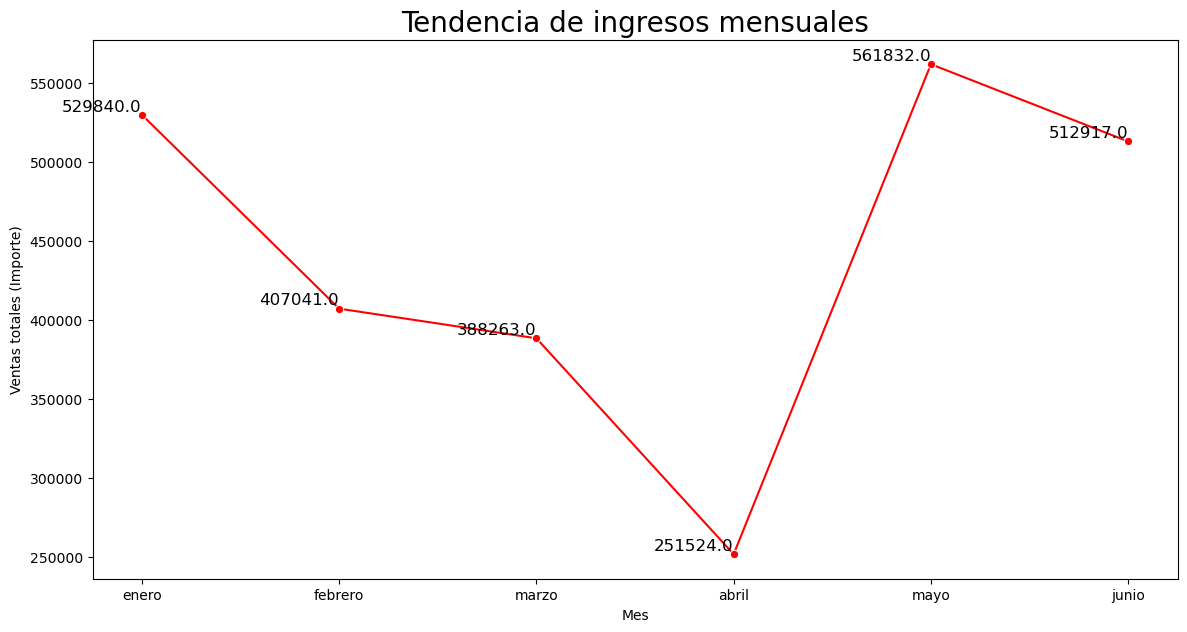

In [21]:
plt.figure(figsize=(14, 7))

# Crear el gráfico de líneas
sns.lineplot(df_tendencia_ingresos, x= 'nombre_mes', y = 'importe', color = 'red', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Ventas totales (Importe)')
plt.title('Tendencia de ingresos mensuales', fontsize = 20)

# Agregar etiquetas sobre cada punto
for i in range(len(df_tendencia_ingresos)):
    plt.text(df_tendencia_ingresos['nombre_mes'][i],
             df_tendencia_ingresos['importe'][i] + 10000,   # Ajusta la altura de la etiqueta
             str(round(df_tendencia_ingresos['importe'][i], 0)),
             ha='right', va='top', fontsize=12, color='black')

plt.show()

## ¿Cómo ha sido la tendencia de la cantidad vendida mensualmente?

In [22]:
query_tendencia_cantidad = ''' 
                               SELECT MONTH(vt.fecha) AS mes, FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, SUM(dv.cantidad) AS cantidad 
                               FROM dbo.detalle_ventas AS dv 
                               INNER JOIN dbo.ventas vt ON vt.id_venta = dv.id_venta
                               GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                               ORDER BY MONTH(vt.fecha) ASC ;
                            '''
df_tendencia_cantidad = pd.read_sql(query_tendencia_cantidad, con)
df_tendencia_cantidad

,mes,nombre_mes,cantidad
0,1,enero,205
1,2,febrero,173
2,3,marzo,149
3,4,abril,100
4,5,mayo,206
5,6,junio,183


Calculamos el crecimiento mes a mes de la cantidad vendida

In [23]:
crecimiento_mes_a_mes = np.zeros(6)
for i in range(6):
    if i == 0:
        crecimiento_mes_a_mes[i] = np.nan
    else:    
        crecimiento_mes_a_mes[i] = round(((df_tendencia_cantidad['cantidad'][i] - df_tendencia_cantidad['cantidad'][i - 1]) / df_tendencia_cantidad['cantidad'][i - 1]) * 100,1)

print(crecimiento_mes_a_mes)

[  nan -15.6 -13.9 -32.9 106.  -11.2]


In [24]:
df_tendencia_cantidad['crecimiento_mes_a_mes (%)'] = crecimiento_mes_a_mes
df_tendencia_cantidad

,mes,nombre_mes,cantidad,crecimiento_mes_a_mes (%)
0,1,enero,205,NaN
1,2,febrero,173,-15.6
2,3,marzo,149,-13.9
3,4,abril,100,-32.9
4,5,mayo,206,106.0
5,6,junio,183,-11.2


Tasa de Crecimiento Mensual Compuesta (CMGR) de la cantidad vendida

In [25]:
CMGR = round((((df_tendencia_cantidad['cantidad'][5] / df_tendencia_cantidad['cantidad'][0]) ** (1 / (df_tendencia_cantidad.shape[0]-1))) - 1) * 100, 1)
print(f'Tasa de Crecimiento Mensual Compuesta = {CMGR}%')

Tasa de Crecimiento Mensual Compuesta = -2.2%


En promedio, las cantidades vendidas de la tienda decrecieron un -2.2% mensual entre enero y junio. 

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


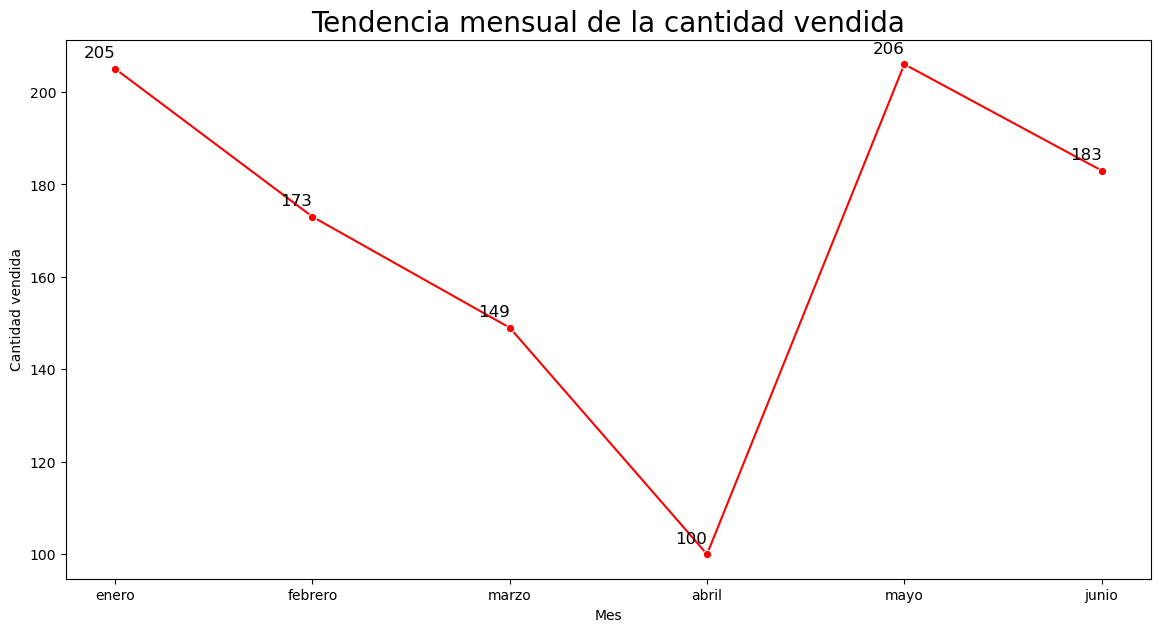

In [26]:
plt.figure(figsize=(14, 7))

# Crear el gráfico de líneas
sns.lineplot(df_tendencia_cantidad, x= 'nombre_mes', y = 'cantidad', color = 'red', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Cantidad vendida')
plt.title("Tendencia mensual de la cantidad vendida", fontsize = 20)

# Agregar etiquetas sobre cada punto
for i in range(len(df_tendencia_cantidad)):
    plt.text(df_tendencia_cantidad['nombre_mes'][i],
             df_tendencia_cantidad['cantidad'][i] + 5,   # Ajusta la altura de la etiqueta
             str(round(df_tendencia_cantidad['cantidad'][i], 0)),
             ha='right', va='top', fontsize=12, color='black')

plt.show()

#### Análisis de la tendencia mensual de la cantidad vendida y los ingresos (importe)

* Primer trimestre (enero–marzo): Se observa una tendencia de descenso constante tanto en la cantidad vendida como en los ingresos generados.

* Abril fue el mes con peor desempeño, registrando los niveles más bajos de ventas e ingresos.

* Mayo alcanzó el pico máximo de ingresos, aunque se ubicó en el segundo lugar en cantidad vendida.

* Enero se posicionó como el segundo mes con mayores ingresos y el primero en cantidad vendida, mostrando un buen inicio de año.

* En junio se registró un leve descenso respecto al pico de mayo; aun así, se ubicó como el tercer mes con mayores ingresos y cantidad vendida.

## ¿Cuál es el método de pago que más se utiliza?

In [36]:
query_ventas_medio_pago = '''
                            SELECT mp.medio_pago,  COUNT(vt.id_venta) AS cantidad_de_ventas
                            FROM dbo.ventas vt
                            INNER JOIN dbo.medio_de_pago mp ON mp.id_medio_pago = vt.id_medio_pago
                            GROUP BY mp.medio_pago
                            ORDER BY COUNT(vt.id_venta) DESC;
                          '''
df_ventas_medio_pago = pd.read_sql(query_ventas_medio_pago, con)
df_ventas_medio_pago

,medio_pago,cantidad_de_ventas
0,efectivo,37
1,qr,30
2,transferencia,27
3,tarjeta,26


In [38]:
len(df_ventas_medio_pago)

4

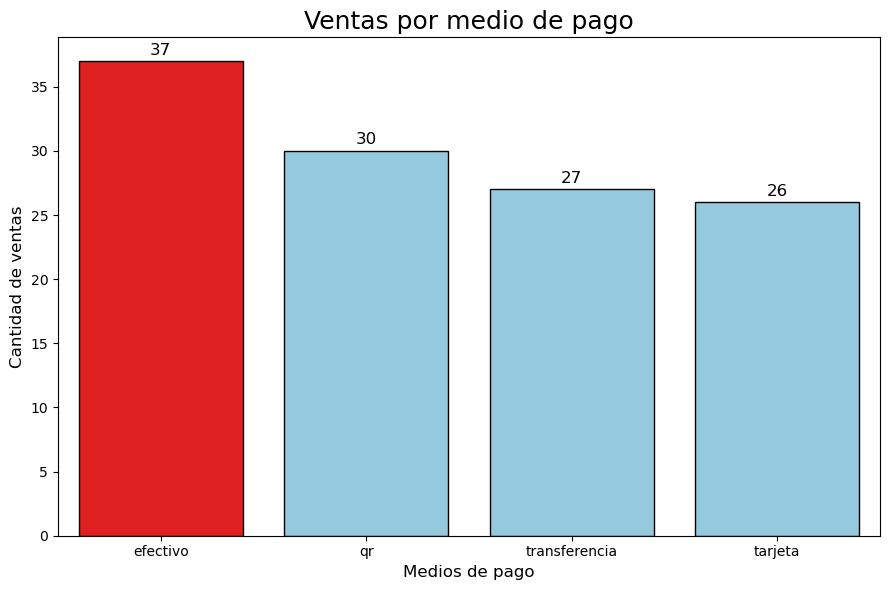

In [39]:
plt.figure(figsize=(9, 6))

# Paleta: primer valor rojo, resto azul suave
colors = ['red'] + ['#87CEEB'] * (len(df_ventas_medio_pago) - 1)

sns.barplot(
    data=df_ventas_medio_pago,
    x='medio_pago',
    y='cantidad_de_ventas',
    palette=colors,
    edgecolor='black'
)

# Títulos y etiquetas
plt.title("Ventas por medio de pago", fontsize=18)
plt.xlabel("Medios de pago", fontsize=12)
plt.ylabel("Cantidad de ventas", fontsize=12)

# Añadir valores encima de cada barra
for i, value in enumerate(df_ventas_medio_pago['cantidad_de_ventas']):
    plt.text(i, value + 0.5, str(value),
             ha='center', fontsize=12, color='black')

# Ajustar layout
plt.tight_layout()
plt.show()

Análisis:

* 37 ventas se realizaron en efectivo. Esto muestra que muchos clientes aún prefieren pagar de forma tradicional, posiblemente por costumbre o comodidad.

* Los pagos digitales (QR, transferencia y tarjeta) en conjunto alcanzan 83 ventas, superando al efectivo. Esto indica que cada vez más personas optan por métodos digitales, reflejando una tendencia creciente hacia la digitalización.

* El método digital más utilizado es el pago mediante QR, ya que representa una alternativa rápida, cómoda y segura para los clientes.

Referencias:
* https://pepperfinance.es/blog/finanzas/8-metodos-pago-online-utilizados/

* https://prometeoapi.com/blog/pagos-digitales

* https://www.santander.com/es/stories/pagos-digitales-que-son-y-cuales-son-los-mas-usados

## ¿En qué ciudades generan más ingresos?

In [73]:
query_ciudad_importe = '''
                        SELECT cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR) AS ciudad, SUM(dv.cantidad * dv.precio_unitario) AS importe 
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR)
                        ORDER BY SUM(dv.cantidad * dv.precio_unitario) DESC;
                       '''
df_ciudad_importe = pd.read_sql(query_ciudad_importe, con)
df_ciudad_importe

,id_ciudad,ciudad,importe
0,2,Rio Cuarto,792203.0
1,5,Alta Gracia,481504.0
2,3,Cordoba,481482.0
3,1,Carlos Paz,353852.0
4,4,Villa Maria,313350.0
5,6,Mendiolaza,229026.0


Calculamos los porcentajes de participación.

In [77]:
porcentaje_participacion = np.zeros(6)

for i in range(6):
    porcentaje_participacion[i]= round((df_ciudad_importe['importe'][i]/df_ciudad_importe['importe'].sum())*100,1)

print(porcentaje_participacion)    
# 2651417.0

[29.9 18.2 18.2 13.3 11.8  8.6]


In [80]:
df_ciudad_importe['porcentaje_participacion (%)'] = porcentaje_participacion
df_ciudad_importe

,id_ciudad,ciudad,importe,porcentaje_participacion,porcentaje_participacion(%),porcentaje_participacion (%)
0,2,Rio Cuarto,792203.0,29.9,29.9,29.9
1,5,Alta Gracia,481504.0,18.2,18.2,18.2
2,3,Cordoba,481482.0,18.2,18.2,18.2
3,1,Carlos Paz,353852.0,13.3,13.3,13.3
4,4,Villa Maria,313350.0,11.8,11.8,11.8
5,6,Mendiolaza,229026.0,8.6,8.6,8.6


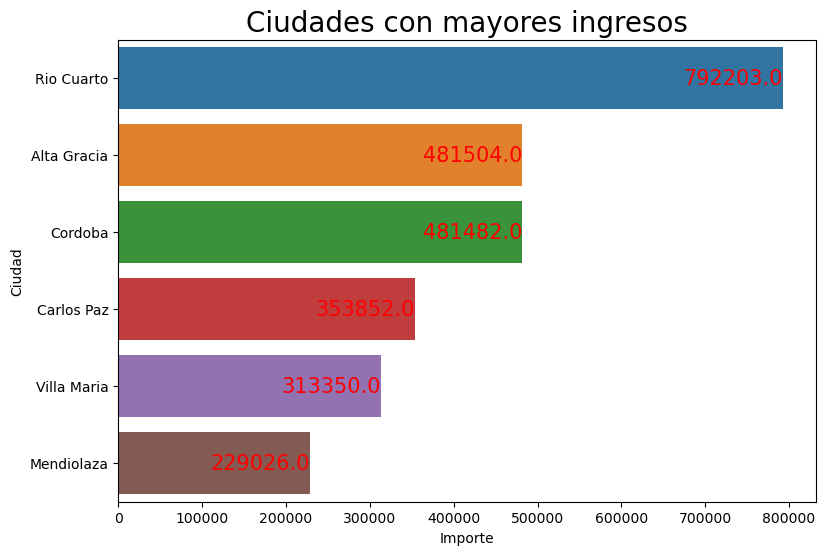

In [82]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_ciudad_importe, y='ciudad', x='importe')
plt.xlabel('Importe')
plt.ylabel('Ciudad')
plt.title('Ciudades con mayores ingresos', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_ciudad_importe['importe']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

## ¿En qué ciudades se realizaron más compras en cantidad?

In [83]:
query_ciudad_cantidad = '''
                        SELECT cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR) AS ciudad, SUM(dv.cantidad) AS cantidad 
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR)
                        ORDER BY SUM(dv.cantidad) DESC;
                       '''
df_ciudad_cantidad = pd.read_sql(query_ciudad_cantidad, con)
df_ciudad_cantidad

,id_ciudad,ciudad,cantidad
0,2,Rio Cuarto,299
1,3,Cordoba,200
2,5,Alta Gracia,185
3,1,Carlos Paz,126
4,4,Villa Maria,106
5,6,Mendiolaza,100


In [85]:
porcentaje_participacion_cantidad = np.zeros(6)

for i in range(6):
    porcentaje_participacion_cantidad[i]= round((df_ciudad_cantidad['cantidad'][i]/df_ciudad_cantidad['cantidad'].sum())*100,1)

print(porcentaje_participacion_cantidad)    

[29.4 19.7 18.2 12.4 10.4  9.8]


In [86]:
df_ciudad_cantidad['porcentaje_participacion (%)'] = porcentaje_participacion_cantidad
df_ciudad_cantidad

,id_ciudad,ciudad,cantidad,porcentaje_participacion (%)
0,2,Rio Cuarto,299,29.4
1,3,Cordoba,200,19.7
2,5,Alta Gracia,185,18.2
3,1,Carlos Paz,126,12.4
4,4,Villa Maria,106,10.4
5,6,Mendiolaza,100,9.8


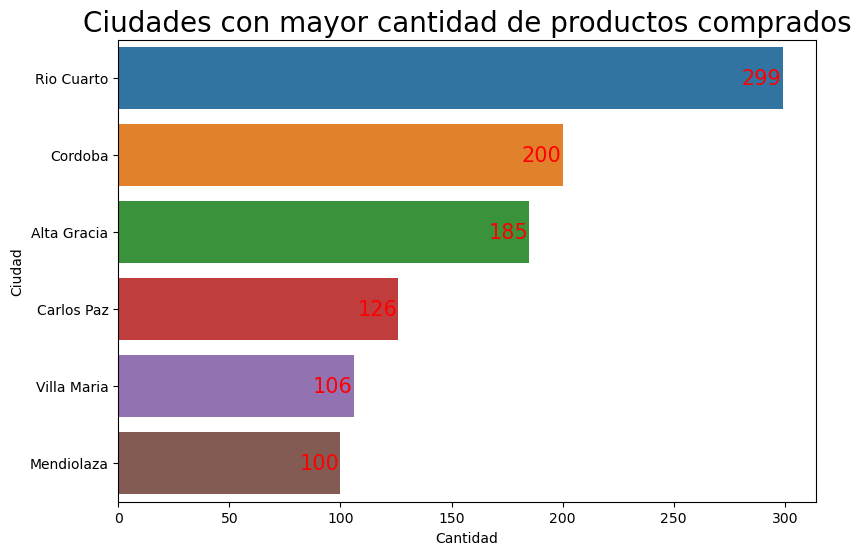

In [87]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_ciudad_cantidad, y='ciudad', x='cantidad')
plt.xlabel('Cantidad')
plt.ylabel('Ciudad')
plt.title('Ciudades con mayor cantidad de productos comprados', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_ciudad_cantidad['cantidad']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

#### Análisis de Ciudades con mayor cantidad de productos comprados y Ciudades con mayores ingresos


* Río Cuarto, Córdoba y Alta Gracia son las principales ciudades generadoras de ingresos y ventas para la tienda Aurelion.

* Río Cuarto, es la ciudad más importante para la tienda, ya que lidera tanto en ingresos como en cantidad de productos vendidos. Esto sugiere una base de clientes sólida, con alto poder adquisitivo y un volumen de compras considerable.

* Córdoba y Alta Gracia, son mercados estables con potencial de crecimiento; conviene impulsar campañas o descuentos dirigidos.

## ¿Quiénes son los 20 clientes que más compran en términos de ingresos?

In [94]:
query_cliente_importe = '''
                        SELECT cl.id_cliente, CAST(cl.nombre_cliente AS VARCHAR) AS cliente, SUM(dv.cantidad * dv.precio_unitario) AS importe	
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cl.id_cliente, CAST(cl.nombre_cliente AS VARCHAR)
                        ORDER BY SUM(dv.cantidad * dv.precio_unitario) DESC;
                        '''
df_cliente_importe = pd.read_sql(query_cliente_importe, con)
df_cliente_importe

,id_cliente,cliente,importe
0,5,Agustina Flores,132158.0
1,56,Bruno Diaz,90701.0
2,52,Diego Diaz,90522.0
3,25,Karina Castro,81830.0
4,1,Mariana Lopez,72448.0
...,...,...,...
62,98,Camila Castro,10864.0
63,51,Agustina Gomez,9800.0
64,17,Pablo Gomez,7752.0
65,82,Lucas Lopez,7710.0


In [107]:
porcentaje_participacion_clientes = np.zeros(len(df_cliente_importe))

for i in range(len(df_cliente_importe)):
    porcentaje_participacion_clientes[i]= round((df_cliente_importe['importe'][i]/df_cliente_importe['importe'].sum())*100,1)

print(porcentaje_participacion_clientes)    

[5.  3.4 3.4 3.1 2.7 2.7 2.6 2.5 2.5 2.4 2.4 2.4 2.4 2.3 2.3 2.2 2.2 2.
 1.9 1.8 1.8 1.7 1.7 1.7 1.6 1.6 1.6 1.5 1.5 1.5 1.4 1.3 1.3 1.3 1.3 1.2
 1.1 1.1 1.1 1.1 1.  1.  1.  1.  1.  1.  0.9 0.9 0.8 0.8 0.8 0.8 0.8 0.8
 0.7 0.7 0.7 0.6 0.6 0.6 0.6 0.5 0.4 0.4 0.3 0.3 0.2]


In [108]:
df_cliente_importe['porcentaje_participacion (%)'] = porcentaje_participacion_clientes
# df_cliente_importe

In [109]:
df_cliente_importe.head(20)

,id_cliente,cliente,importe,porcentaje_participacion (%)
0,5,Agustina Flores,132158.0,5.0
1,56,Bruno Diaz,90701.0,3.4
2,52,Diego Diaz,90522.0,3.4
3,25,Karina Castro,81830.0,3.1
4,1,Mariana Lopez,72448.0,2.7
5,49,Olivia Gomez,71321.0,2.7
6,61,Guadalupe Martinez,67959.0,2.6
7,84,Pablo Sanchez,67575.0,2.5
8,72,Camila Rodriguez,65001.0,2.5
9,39,Santiago Diaz,64786.0,2.4


#### Análisis:

* Agustina Flores destaca como la clienta que más ingresos generó para la tienda, posicionándose como la principal contribuyente en términos de ventas totales.

* Bruno Diaz, Diego Diaz y Karina Castro ocupan las siguientes posiciones, con montos que oscilan entre 81830.0 y 90,000, lo que evidencia un segmento de clientes con alto nivel de gasto y potencial valor para la empresa.

In [28]:
df_detalle_ventas[df_detalle_ventas['importe'] > limite_superior_importe]

,id_venta,id_producto,cantidad,precio_unitario,importe
41,16,35,5,4430.0,22150.0
55,21,76,5,4286.0,21430.0
142,50,58,5,4752.0,23760.0
176,63,8,5,4218.0,21090.0
207,75,2,5,4973.0,24865.0
260,94,86,5,4090.0,20450.0
307,110,6,5,4170.0,20850.0


In [29]:
query_productos_mayores_al_limite_superior_importe = '''
                                                     SELECT * FROM dbo.productos 
                                                     WHERE id_producto	IN (35,76,58,8,2,86,6);
                                                    '''

df_productos_mayores_al_limite_superior_importe = pd.read_sql(query_productos_mayores_al_limite_superior_importe, con)
df_productos_mayores_al_limite_superior_importe

,id_producto,nombre_producto,precio_unitario,id_categoria
0,2,Pepsi 1.5L,4973.0,2
1,6,Jugo de Naranja 1L,4170.0,2
2,8,Energética Nitro 500ml,4218.0,2
3,35,Barrita de Cereal 30g,4430.0,1
4,58,Caramelos Masticables,4752.0,2
5,76,Pizza Congelada Muzzarella,4286.0,2
6,86,Jugo en Polvo Limón,4090.0,2


### ¿Cuál es el ingreso total generado?

In [30]:
query1 = "SELECT * FROM dbo.detalle_ventas"
# leemos nuestra consulta

df_detalle_ventas = pd.read_sql(query1, con)
df


NameError: name 'df' is not defined

In [ ]:
# Definimos nuestras variables para la conexión con autenticación de windows
server = 'localhost',
name_database= 'Proyecto_Tienda_Aurelion'

# Realizamos la conexión de a la base de datos SQL Server
engine = create_engine(
    f"mssql+pyodbc://@{server}/{name_database}?driver=ODBC+Driver+18+for+SQL+Server")

#engine = create_engine("mssql+pyodbc://@"+server+"/"+name_database+"?driver=ODBC+Driver+17+for+SQL+Server")
con = engine.connect() 

OperationalError: (pyodbc.OperationalError) ('08001', "[08001] [Microsoft][ODBC Driver 18 for SQL Server]SQL Server Network Interfaces: Connection string is not valid [87].  (87) (SQLDriverConnect); [08001] [Microsoft][ODBC Driver 18 for SQL Server]Login timeout expired (0); [08001] [Microsoft][ODBC Driver 18 for SQL Server]A network-related or instance-specific error has occurred while establishing a connection to ('localhost',). Server is not found or not accessible. Check if instance name is correct and if SQL Server is configured to allow remote connections. For more information see SQL Server Books Online. (87)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)